# Ecommerce Sales Analysis

## Project Overview

This project applies Exploratory Data Analysis (EDA) techniques to an e-commerce sales dataset.

The objective is to identify customer behavior patterns, revenue drivers and business opportunities through data cleaning, feature engineering and data visualization.


## Importing Libraries

The following libraries are used for data manipulation, analysis and visualization.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

# Mostrar gráficos dentro del notebook
%matplotlib inline

In [3]:
df = pd.read_csv("../data/raw/ecommerce_sales_data.csv")

In [4]:
df.head()

,TransactionID,CustomerID,ProductID,ProductCategory,Quantity,Price,Discount,TransactionDate,PaymentMethod,CustomerLocation,CustomerAge,CustomerGender,CustomerIncomeGroup,CustomerLoyaltyScore
0,1,8270,295,Clothing,1,801.66,0.13,2023-12-22 10:35:26,Cash on Delivery,New Juan,46,Female,Medium,83.36
1,2,1860,546,Beauty,1,225.03,0.06,2024-05-05 10:40:33,Debit Card,South Julie,59,Other,High,58.88
2,3,6390,430,Toys,2,544.99,0.24,2023-12-04 05:22:59,Debit Card,West Carrieview,61,Female,High,53.99
3,4,6191,807,Beauty,2,157.02,0.01,2024-01-02 11:11:00,Bank Transfer,Christianberg,69,Female,Low,11.73
4,5,6734,319,Electronics,2,155.51,0.14,2024-06-18 01:01:29,Debit Card,South Williamhaven,29,Other,High,34.79


In [5]:
df.shape

(100000, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TransactionID         100000 non-null  int64  
 1   CustomerID            100000 non-null  int64  
 2   ProductID             100000 non-null  int64  
 3   ProductCategory       100000 non-null  str    
 4   Quantity              100000 non-null  int64  
 5   Price                 100000 non-null  float64
 6   Discount              100000 non-null  float64
 7   TransactionDate       100000 non-null  str    
 8   PaymentMethod         100000 non-null  str    
 9   CustomerLocation      100000 non-null  str    
 10  CustomerAge           100000 non-null  int64  
 11  CustomerGender        100000 non-null  str    
 12  CustomerIncomeGroup   100000 non-null  str    
 13  CustomerLoyaltyScore  100000 non-null  float64
dtypes: float64(3), int64(5), str(6)
memory usage: 10.7 MB


## Data Quality Assessment

Evaluating data quality is a critical step in any EDA process.

The following checks are performed:

- Missing values
- Duplicate records
- Data types consistency
- General dataset structure

In [7]:
df.isnull().sum()

TransactionID           0
CustomerID              0
ProductID               0
ProductCategory         0
Quantity                0
Price                   0
Discount                0
TransactionDate         0
PaymentMethod           0
CustomerLocation        0
CustomerAge             0
CustomerGender          0
CustomerIncomeGroup     0
CustomerLoyaltyScore    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,TransactionID,CustomerID,ProductID,Quantity,Price,Discount,CustomerAge,CustomerLoyaltyScore
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,5504.000280,550.554140,2.499750,501.469993,0.149962,43.381210,50.004314
std,28867.657797,2600.472561,260.256267,1.118353,287.536905,0.086638,15.030994,28.888185
min,1.000000,1000.000000,100.000000,1.000000,5.010000,0.000000,18.000000,0.000000
25%,25000.750000,3251.000000,325.000000,1.000000,251.537500,0.070000,30.000000,24.920000
50%,50000.500000,5511.000000,552.000000,3.000000,501.580000,0.150000,43.000000,49.920000
75%,75000.250000,7751.000000,777.000000,3.000000,750.397500,0.220000,56.000000,75.070000
max,100000.000000,9999.000000,999.000000,4.000000,1000.000000,0.300000,69.000000,100.000000


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TransactionID         100000 non-null  int64  
 1   CustomerID            100000 non-null  int64  
 2   ProductID             100000 non-null  int64  
 3   ProductCategory       100000 non-null  str    
 4   Quantity              100000 non-null  int64  
 5   Price                 100000 non-null  float64
 6   Discount              100000 non-null  float64
 7   TransactionDate       100000 non-null  str    
 8   PaymentMethod         100000 non-null  str    
 9   CustomerLocation      100000 non-null  str    
 10  CustomerAge           100000 non-null  int64  
 11  CustomerGender        100000 non-null  str    
 12  CustomerIncomeGroup   100000 non-null  str    
 13  CustomerLoyaltyScore  100000 non-null  float64
dtypes: float64(3), int64(5), str(6)
memory usage: 10.7 MB


## Data Cleaning and Feature Engineering

In [11]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [12]:
df["TransactionDate"].head()


0   2023-12-22 10:35:26
1   2024-05-05 10:40:33
2   2023-12-04 05:22:59
3   2024-01-02 11:11:00
4   2024-06-18 01:01:29
Name: TransactionDate, dtype: datetime64[us]

## Feature Engineering

To support business-oriented analysis, new variables are created from the original dataset.

These features allow us to better understand revenue generation, customer segmentation and sales trends.

### Revenue Calculation

Revenue is calculated as:

Revenue = Quantity × Price × (1 - Discount)

This new variable represents the actual income generated by each transaction after applying discounts.

In [14]:
df["Revenue"] = (
    df["Quantity"]
    * df["Price"]
    * (1 - df["Discount"])
)

In [16]:
df["Month"] = df["TransactionDate"].dt.month
df["Year"] = df["TransactionDate"].dt.year

### Customer Segmentation by Age

Customers are grouped into age ranges to facilitate demographic analysis and identify purchasing patterns across different age groups.

In [18]:
df["AgeGroup"] = pd.cut(
    df["CustomerAge"],
    bins=[18,25,35,50,70],
    labels=["18-25","26-35","36-50","50+"]
)

df[["Revenue"]].describe()


,Revenue
count,100000.000000
mean,1066.595342
std,834.202849
min,3.818400
25%,407.297700
50%,823.846050
75%,1568.684700
max,3971.280000


In [19]:
df.head()

,TransactionID,CustomerID,ProductID,ProductCategory,Quantity,Price,Discount,TransactionDate,PaymentMethod,CustomerLocation,CustomerAge,CustomerGender,CustomerIncomeGroup,CustomerLoyaltyScore,Revenue,Month,Year,AgeGroup
0,1,8270,295,Clothing,1,801.66,0.13,2023-12-22 10:35:26,Cash on Delivery,New Juan,46,Female,Medium,83.36,697.4442,12,2023,36-50
1,2,1860,546,Beauty,1,225.03,0.06,2024-05-05 10:40:33,Debit Card,South Julie,59,Other,High,58.88,211.5282,5,2024,50+
2,3,6390,430,Toys,2,544.99,0.24,2023-12-04 05:22:59,Debit Card,West Carrieview,61,Female,High,53.99,828.3848,12,2023,50+
3,4,6191,807,Beauty,2,157.02,0.01,2024-01-02 11:11:00,Bank Transfer,Christianberg,69,Female,Low,11.73,310.8996,1,2024,50+
4,5,6734,319,Electronics,2,155.51,0.14,2024-06-18 01:01:29,Debit Card,South Williamhaven,29,Other,High,34.79,267.4772,6,2024,26-35


## Revenue Overview

Revenue is the primary business metric used throughout this analysis.

The following descriptive statistics provide an initial understanding of transaction value distribution and potential variability across the dataset.

## Revenue Distribution Analysis

Revenue is the main business metric used throughout this analysis.

Understanding how transaction revenue is distributed helps identify customer purchasing patterns, transaction variability and the potential presence of high-value sales.

This analysis serves as a foundation for understanding the overall sales performance of the e-commerce business.

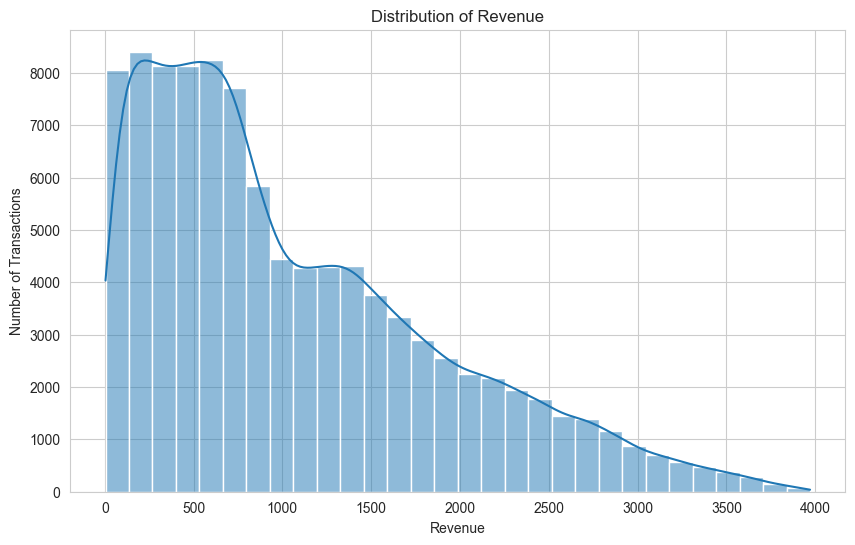

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Revenue"],
    bins=30,
    kde=True
)

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Transactions")

plt.show()


### Interpretation

This visualization shows how transaction revenue is distributed across the dataset.

The relationship between the average revenue and the overall distribution helps identify whether most purchases are concentrated around similar values or whether a small number of high-value transactions significantly influence total revenue.

## Revenue by Product Category

Product categories are one of the most important drivers of revenue.

This analysis evaluates which categories generate the highest revenue and therefore contribute most to the overall business performance.

Understanding category performance can support inventory planning, marketing investment and strategic decision-making.

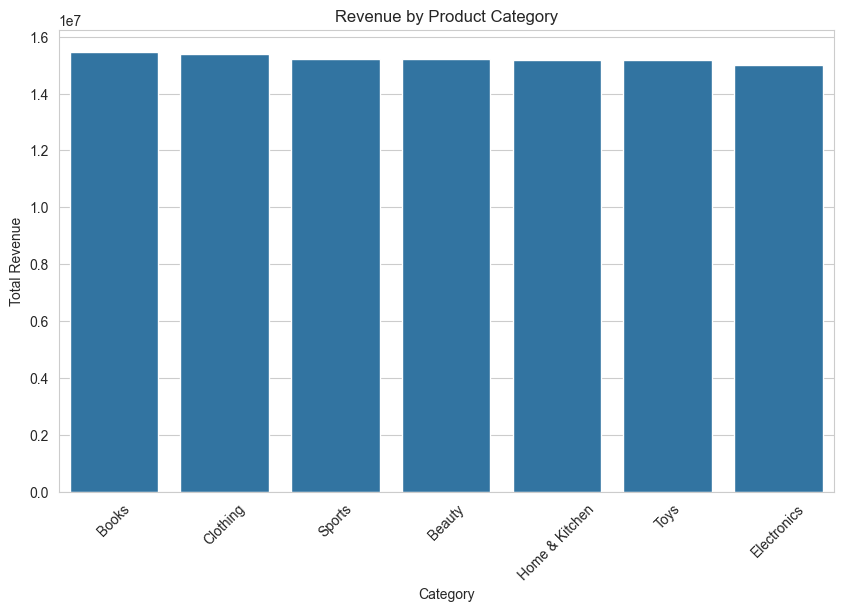

In [22]:
category_revenue = (
    df.groupby("ProductCategory")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

### Interpretation

Revenue appears to be relatively balanced across all product categories, with no single category significantly outperforming the others.

This suggests a diversified revenue structure in which sales are distributed across multiple product segments rather than being concentrated in a small number of categories.

From a business perspective, this reduces dependency on individual product categories and may indicate a more stable revenue portfolio.

## Customer Loyalty and Revenue

Customer retention is one of the most important drivers of long-term profitability in e-commerce.

This analysis investigates whether customers with higher loyalty scores tend to generate more revenue than less loyal customers.

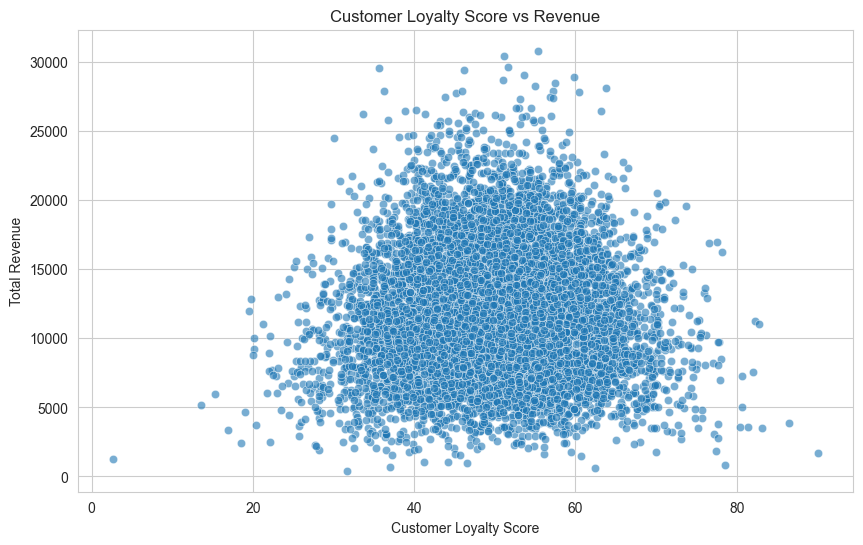

In [23]:
customer_revenue = (
    df.groupby("CustomerID")
      .agg({
          "Revenue": "sum",
          "CustomerLoyaltyScore": "mean"
      })
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_revenue,
    x="CustomerLoyaltyScore",
    y="Revenue",
    alpha=0.6
)

plt.title("Customer Loyalty Score vs Revenue")
plt.xlabel("Customer Loyalty Score")
plt.ylabel("Total Revenue")

plt.show()

### Interpretation

The scatter plot does not reveal a strong linear relationship between customer loyalty score and total revenue.

Customers with both high and low loyalty scores generate a wide range of revenue values, suggesting that loyalty alone is not a strong predictor of spending behavior within this dataset.

While loyalty may still contribute to customer retention, additional factors such as product preferences, purchasing frequency or income level may have a greater influence on revenue generation.

## Revenue by Income Group

Customer income level can significantly influence purchasing behavior and transaction value.

This analysis explores whether customers from different income groups generate different levels of revenue and contribute unequally to overall business performance.

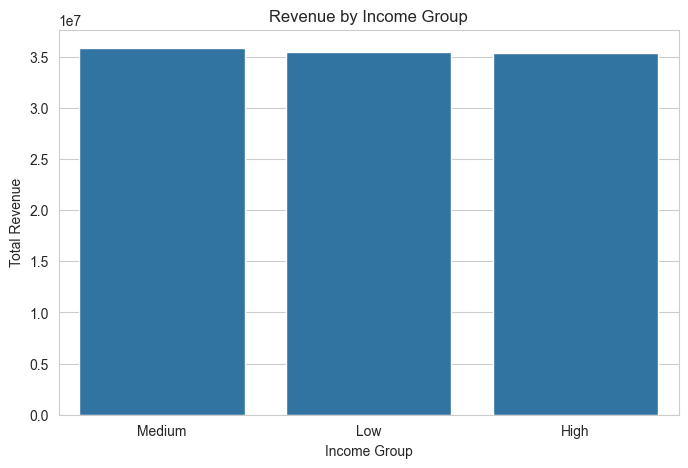

In [ ]:
income_revenue = (
    df.groupby("CustomerIncomeGroup")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=income_revenue.index,
    y=income_revenue.values
)

plt.title("Revenue by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Total Revenue")

plt.show()

### Interpretation

Revenue contribution appears remarkably balanced across all income groups.

Unlike many real-world e-commerce datasets, no customer segment dominates total revenue generation.

This suggests a diversified customer base and may also indicate that the dataset was designed with a relatively uniform distribution of purchasing behavior across income levels.

As a result, customer income alone does not appear to be a strong differentiator of revenue within this dataset.

## Revenue Trends Over Time

Time-based analysis helps identify seasonal patterns, growth trends and fluctuations in customer purchasing behavior.

Understanding how revenue changes across different months can support forecasting, campaign planning and resource allocation.

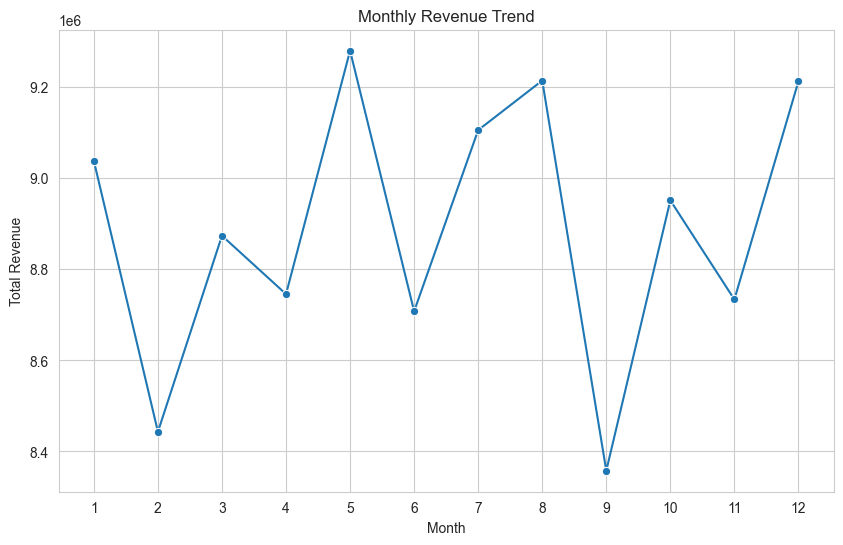

In [25]:
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=monthly_revenue,
    x="Month",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(range(1,13))

plt.show()

### Interpretation

The monthly revenue trend shows moderate fluctuations throughout the year, with stronger performance observed in May, August and December, while February and September appear to generate comparatively lower revenue.

Although revenue varies across months, the overall pattern remains relatively stable, suggesting that sales activity is distributed consistently throughout the year.

The absence of extreme peaks or declines indicates a balanced sales structure with limited dependence on specific seasonal periods.

## High Value Customer Identification

Not all customers contribute equally to revenue generation.

To better understand customer segmentation, a new feature is created to identify high-value customers based on transaction revenue.

Transactions above the 75th percentile are classified as "High Value", while the remaining transactions are classified as "Regular".

In [26]:
df["HighValueCustomer"] = np.where(
    df["Revenue"] > df["Revenue"].quantile(0.75),
    "High Value",
    "Regular"
)

In [27]:
df["HighValueCustomer"].value_counts()

HighValueCustomer
Regular       75000
High Value    25000
Name: count, dtype: int64

### Interpretation

The segmentation process classified approximately 25% of transactions as High Value and 75% as Regular.

This result is expected because the threshold was defined using the 75th percentile of transaction revenue.

The new feature creates a business-oriented segmentation that can be used to compare customer behavior, demographic characteristics and revenue contribution across different customer groups.

### Feature Engineering Rationale

The original dataset did not contain a customer value classification.

The HighValueCustomer variable was created to transform a continuous revenue measure into a business-oriented segment that can support customer analysis and strategic decision-making.

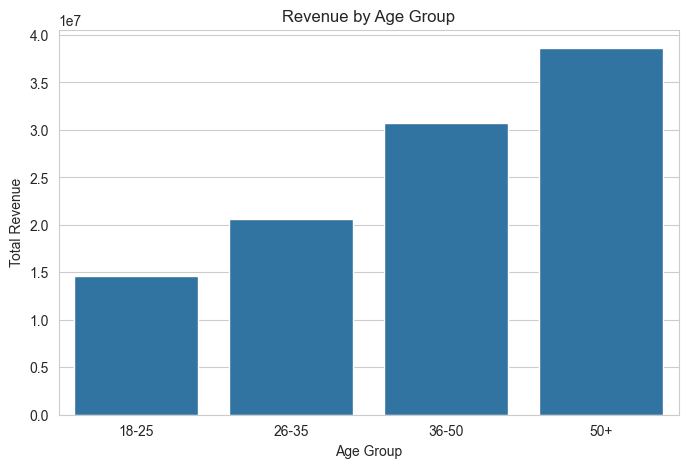

In [30]:
age_revenue = (
    df.groupby("AgeGroup")["Revenue"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=age_revenue,
    x="AgeGroup",
    y="Revenue"
)

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")

plt.show()

## Average Revenue by Age Group

While total revenue highlights the contribution of each age segment, it does not account for differences in the number of transactions.

To better understand purchasing behavior, the average revenue per transaction is analyzed across age groups.

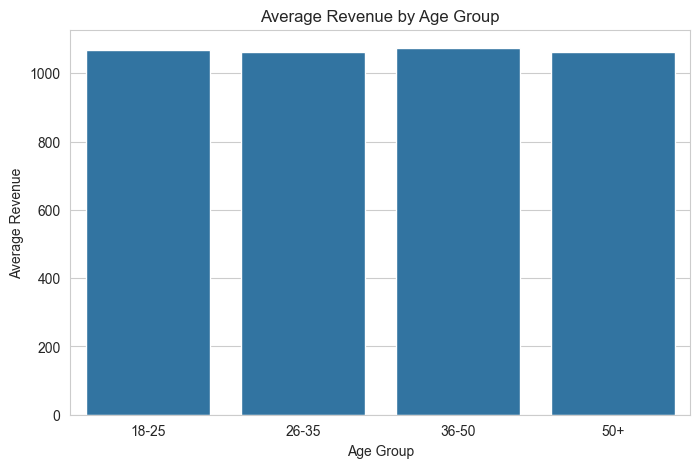

In [31]:
avg_age_revenue = (
    df.groupby("AgeGroup")["Revenue"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_age_revenue,
    x="AgeGroup",
    y="Revenue"
)

plt.title("Average Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Revenue")

plt.show()

### Interpretation

Although older age groups appeared to contribute more total revenue, the analysis of average transaction revenue reveals very similar spending patterns across all age segments.

This suggests that age does not significantly influence the value of individual transactions within the dataset.

The differences observed in total revenue are therefore more likely related to transaction volume rather than purchasing behavior.

### Correlation Matrix

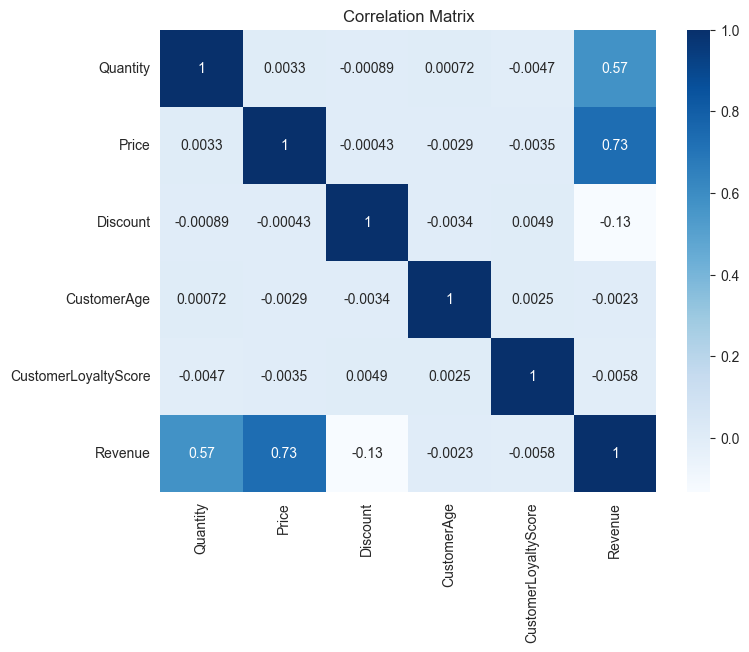

In [32]:
correlation_matrix = df[
    [
        "Quantity",
        "Price",
        "Discount",
        "CustomerAge",
        "CustomerLoyaltyScore",
        "Revenue"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

### Interpretation

The correlation analysis reveals that Price and Quantity are the strongest drivers of revenue generation, showing positive relationships of 0.73 and 0.57 respectively.

Discount exhibits a weak negative correlation with revenue, indicating that higher discounts tend to reduce transaction value.

Customer Age and Customer Loyalty Score show almost no correlation with revenue, suggesting that demographic and loyalty-related factors are not strong predictors of spending behavior within this dataset.

These findings reinforce the importance of product pricing and purchase volume as the primary determinants of revenue performance.

## Top Customers Analysis

Customer concentration is an important business metric.

Understanding whether a small group of customers generates a significant portion of total revenue can help identify key accounts and evaluate business dependency risks.

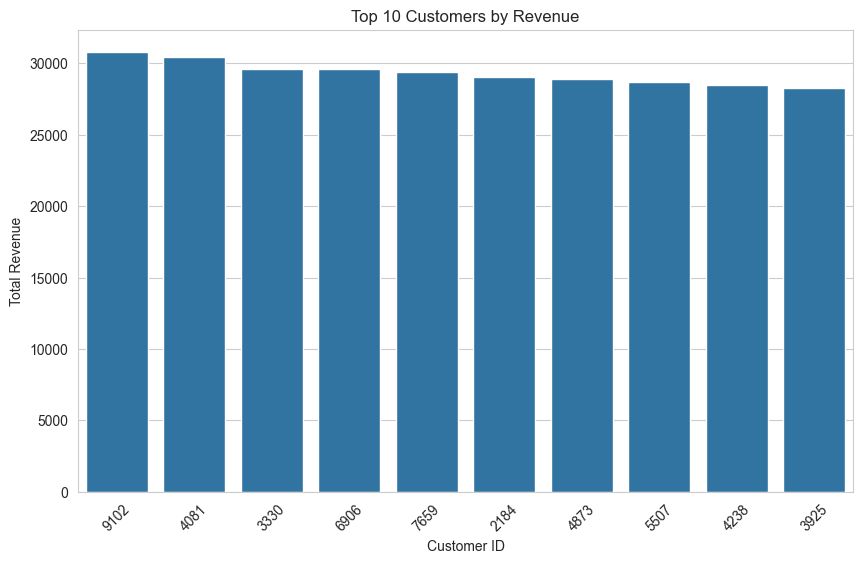

In [33]:
top_customers = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_customers.index.astype(str),
    y=top_customers.values
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

In [34]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

top_10_share = (
    customer_revenue.head(10).sum()
    / customer_revenue.sum()
) * 100

print(
    f"Top 10 customers generate {top_10_share:.2f}% of total revenue"
)

Top 10 customers generate 0.27% of total revenue


### Interpretation

The top 10 customers account for only 0.27% of total revenue, indicating an extremely diversified customer base.

Unlike businesses that depend heavily on a small number of key accounts, revenue in this dataset is broadly distributed across thousands of customers.

This diversification reduces customer dependency risk and contributes to overall business stability.

# Key Findings

## Finding 1: Revenue Distribution Is Positively Skewed

Most transactions generate moderate revenue values, while a smaller number of high-value transactions contribute disproportionately to total revenue.

The difference between mean and median revenue confirms the presence of higher-value purchases that increase the overall average transaction value.

## Finding 2: Revenue Is Evenly Distributed Across Product Categories

No single product category dominates total revenue generation.

Sales appear relatively balanced across all categories, suggesting a diversified product portfolio and reduced dependency on specific segments.

## Finding 3: Customer Loyalty Shows Limited Influence on Revenue

The analysis revealed no strong relationship between Customer Loyalty Score and total revenue.

Customers with both high and low loyalty scores generated a wide range of revenue values, indicating that loyalty alone is not a strong predictor of spending behavior.

## Finding 4: Customer Income Group Does Not Significantly Differentiate Revenue

Revenue contribution was remarkably similar across low, medium and high income groups.

This suggests that customer income is not a major driver of purchasing behavior within this dataset.

## Finding 5: Revenue Varies Moderately Throughout the Year

Monthly revenue trends show fluctuations across the year, with stronger performance observed in May, August and December.

However, the overall pattern remains relatively stable, indicating limited seasonality.

## Finding 6: Age Influences Total Revenue Contribution but Not Average Spending

Older age groups contributed more total revenue.

However, average transaction revenue remained similar across all age groups, suggesting that differences are primarily driven by transaction volume rather than spending behavior.

## Finding 7: Price and Quantity Are the Main Revenue Drivers

Correlation analysis identified Price (0.73) and Quantity (0.57) as the variables most strongly associated with revenue generation.

These findings confirm that transaction value is primarily driven by product pricing and purchase volume.

## Finding 8: Revenue Is Highly Diversified Across Customers

The top 10 customers generate only 0.27% of total revenue.

This indicates an extremely diversified customer base and a very low dependency on individual customers.

# Business Recommendations

Based on the exploratory analysis, the following recommendations can be considered:

1. Continue maintaining a diversified product portfolio, as revenue is balanced across categories.

2. Prioritize pricing and sales volume strategies, as these variables show the strongest relationship with revenue generation.

3. Monitor discount policies carefully, since discounts show a negative relationship with revenue.

4. Investigate additional customer behavior variables, as loyalty score and income group alone do not explain purchasing patterns.

5. Leverage the stable customer base and low concentration risk to support long-term growth initiatives.

6. Explore seasonal campaigns during stronger-performing months to maximize revenue opportunities.

# Conclusion

This project applied Exploratory Data Analysis (EDA) techniques to a dataset containing 100,000 e-commerce transactions.

The analysis included data quality assessment, feature engineering, descriptive statistics, correlation analysis and business-oriented visualizations.

Several insights were identified regarding revenue generation, customer behavior, product performance and revenue concentration.

The results indicate that revenue is primarily influenced by product pricing and purchase volume, while demographic and loyalty-related variables show limited predictive value.

Overall, the business represented by this dataset demonstrates a highly diversified customer base, balanced category performance and relatively stable revenue patterns throughout the year.

The project successfully transformed raw transactional data into actionable business insights that can support data-driven decision making.

# Next Steps

Future analysis could explore:

- Customer segmentation techniques
- Customer lifetime value (CLV)
- Predictive revenue modeling
- Product recommendation systems
- Advanced customer behavior analysis